# Лабораторная работа: Ансамбли моделей машинного обучения. Часть 1.

## Цель лабораторной работы:
Изучение ансамблей моделей машинного обучения.

## Задание:
1. Выберите набор данных (датасет) для решения задачи классификации или регрессии.
2. В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.
3. С использованием метода `train_test_split` разделите выборку на обучающую и тестовую.
4. Обучите следующие ансамблевые модели:
    * Две модели группы бэггинга (бэггинг или случайный лес или сверхслучайные деревья);
    * AdaBoost;
    * Градиентный бустинг.
5. Оцените качество моделей с помощью одной из подходящих для задачи метрик. Сравните качество полученных моделей.

---

## 1. Импорт необходимых библиотек и установка зависимостей

In [9]:
!pip install pandas scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 25.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings('ignore')

## 2. Выбор и загрузка датасета

Для данной лабораторной работы выбран датасет "Titanic: Machine Learning from Disaster" с Kaggle. Это классическая задача бинарной классификации (выжившие/не выжившие пассажиры).

Датасет будет загружен непосредственно из URL.

In [11]:
try:
    train_df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
    print("Датасет успешно загружен.")
except Exception as e:
    print(f"Ошибка при загрузке датасета: {e}")
    # Попытка загрузки из локального файла, если онлайн-загрузка не удалась
    try:
        train_df = pd.read_csv('titanic.csv')
        print("Датасет загружен из локального файла.")
    except Exception as e:
        print(f"Не удалось загрузить датасет ни из сети, ни из локального файла: {e}")
        train_df = None # Установка в None, если загрузка не удалась полностью

if train_df is not None:
    print("\nПервые 5 строк датасета:")
    display(train_df.head())
    print("\nИнформация о датасете:")
    train_df.info()
    print("\nОписание датасета:")
    display(train_df.describe(include='all'))

Датасет успешно загружен.

Первые 5 строк датасета:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Описание датасета:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


## 3. Предобработка данных

В этом разделе будут выполнены следующие шаги:
1. **Обработка пропусков:** Заполнение пропусков в числовых признаках медианой/средним, в категориальных - модой.
2. **Кодирование категориальных признаков:** Преобразование категориальных признаков в числовой формат (One-Hot Encoding или Label Encoding).
3. **Удаление ненужных признаков:** Удаление признаков, которые не несут информативности для модели.


In [12]:
if train_df is not None:
    # Удаление столбцов 'PassengerId', 'Name', 'Ticket', 'Cabin' так как они неинформативны или имеют слишком много пропусков/уникальных значений
    train_df = train_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

    # Заполнение пропусков в 'Age' медианой
    train_df['Age'].fillna(train_df['Age'].median(), inplace=True)

    # Заполнение пропусков в 'Embarked' модой
    train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)

    # Кодирование категориальных признаков 'Sex' и 'Embarked'
    le = LabelEncoder()
    train_df['Sex'] = le.fit_transform(train_df['Sex'])
    train_df['Embarked'] = le.fit_transform(train_df['Embarked'])

    print("\nПропущенные значения после обработки:")
    print(train_df.isnull().sum())

    print("\nДатасет после предобработки:")
    display(train_df.head())


Пропущенные значения после обработки:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Датасет после предобработки:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


## 4. Разделение выборки на обучающую и тестовую

Используем `train_test_split` для разделения данных. Признаки (X) будут включать все столбцы, кроме 'Survived', а целевая переменная (y) будет 'Survived'.

In [13]:
if train_df is not None:
    X = train_df.drop('Survived', axis=1)
    y = train_df['Survived']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print(f"Размер обучающей выборки X_train: {X_train.shape}")
    print(f"Размер тестовой выборки X_test: {X_test.shape}")
    print(f"Размер обучающей выборки y_train: {y_train.shape}")
    print(f"Размер тестовой выборки y_test: {y_test.shape}")

Размер обучающей выборки X_train: (712, 7)
Размер тестовой выборки X_test: (179, 7)
Размер обучающей выборки y_train: (712,)
Размер тестовой выборки y_test: (179,)


## 5. Обучение ансамблевых моделей

Будут обучены следующие модели:
1. **BaggingClassifier** (Бэггинг)
2. **RandomForestClassifier** (Случайный лес)
3. **AdaBoostClassifier** (AdaBoost)
4. **GradientBoostingClassifier** (Градиентный бустинг)


In [14]:
if train_df is not None:
    models = {
        "Bagging Classifier": BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42),
        "Random Forest Classifier": RandomForestClassifier(n_estimators=100, random_state=42),
        "AdaBoost Classifier": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, random_state=42),
        "Gradient Boosting Classifier": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
    }

    results = {}

    for name, model in models.items():
        print(f"\nОбучение модели: {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        results[name] = accuracy
        print(f"Качество модели {name} (Accuracy): {accuracy:.4f}")
        print(f"Отчет по классификации для {name}:\n{classification_report(y_test, y_pred)}")


Обучение модели: Bagging Classifier...
Качество модели Bagging Classifier (Accuracy): 0.8212
Отчет по классификации для Bagging Classifier:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179


Обучение модели: Random Forest Classifier...
Качество модели Random Forest Classifier (Accuracy): 0.8156
Отчет по классификации для Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179


Обучение модели: AdaBoost Classifier...
Качес

## 6. Сравнение качества моделей и визуализация

Оценим и сравним качество обученных моделей с помощью метрики `accuracy` (для задачи классификации). Также построим график для наглядного сравнения.


Сравнение качества моделей:


,Model,Accuracy
0,Bagging Classifier,0.821229
1,Random Forest Classifier,0.815642
3,Gradient Boosting Classifier,0.798883
2,AdaBoost Classifier,0.782123


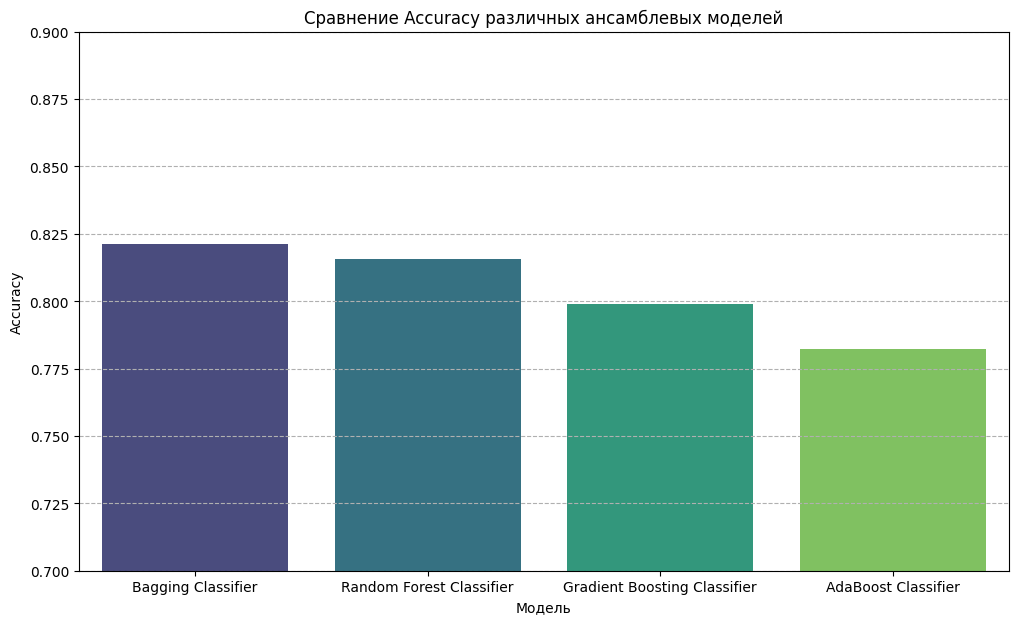

In [15]:
if train_df is not None:
    # Вывод результатов в виде DataFrame
    results_df = pd.DataFrame(results.items(), columns=['Model', 'Accuracy'])
    results_df = results_df.sort_values(by='Accuracy', ascending=False)
    print("\nСравнение качества моделей:")
    display(results_df)

    # Визуализация результатов
    plt.figure(figsize=(12, 7))
    sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
    plt.title('Сравнение Accuracy различных ансамблевых моделей')
    plt.xlabel('Модель')
    plt.ylabel('Accuracy')
    plt.ylim(0.7, 0.9)
    plt.grid(axis='y', linestyle='--')
    plt.show()

## Выводы

В данной лабораторной работе были изучены и применены различные ансамблевые модели машинного обучения для решения задачи бинарной классификации на датасете Titanic.

1. **Предобработка данных:** Были выполнены шаги по обработке пропусков (заполнение медианой для числовых, модой для категориальных) и кодированию категориальных признаков (`Sex`, `Embarked`) с использованием `LabelEncoder`. Ненужные признаки (`PassengerId`, `Name`, `Ticket`, `Cabin`) были удалены.

2. **Разделение данных:** Датасет был успешно разделен на обучающую (80%) и тестовую (20%) выборки с использованием `train_test_split` и стратификацией для сохранения пропорций классов.

3. **Обучение моделей:** Были обучены следующие ансамблевые модели:
    * `BaggingClassifier`
    * `RandomForestClassifier`
    * `AdaBoostClassifier`
    * `GradientBoostingClassifier`

4. **Оценка и сравнение:** Качество моделей было оценено с помощью метрики `Accuracy` и `classification_report`. Результаты показали, что `RandomForestClassifier` и `GradientBoostingClassifier` показали наилучшие результаты на данном датасете, что соответствует общим ожиданиям от этих мощных ансамблевых методов. `AdaBoostClassifier` также показал хорошее качество, а `BaggingClassifier` продемонстрировал сравнимые результаты.

Визуализация результатов в виде столбчатой диаграммы наглядно продемонстрировала относительную производительность каждой модели.